In [14]:
!pip install clustering-benchmarks -q

In [15]:
import clustbench
data_url = "https://github.com/gagolews/clustering-data-v1/raw/v1.1.0"

In [16]:
battery_datasets_dict = {
                         'fcps': ['atom', 'chainlink', 'engytime', 'hepta', 'lsun', 'target', 'tetra', 'twodiamonds', 'wingnut'],
                         'g2mg': ['g2mg_4_10', 'g2mg_4_20', 'g2mg_4_30', 'g2mg_4_40', 'g2mg_4_50', 'g2mg_4_60', 'g2mg_4_70', 'g2mg_4_80', 'g2mg_4_90', 'g2mg_8_10', 'g2mg_8_20', 'g2mg_8_30', 'g2mg_8_40', 'g2mg_8_50', 'g2mg_8_60', 'g2mg_8_70', 'g2mg_8_80', 'g2mg_8_90', 'g2mg_16_10', 'g2mg_16_20', 'g2mg_16_30', 'g2mg_16_40', 'g2mg_16_50', 'g2mg_16_60', 'g2mg_16_70', 'g2mg_16_80', 'g2mg_16_90', 'g2mg_32_10', 'g2mg_32_20', 'g2mg_32_30', 'g2mg_32_40', 'g2mg_32_50', 'g2mg_32_60', 'g2mg_32_70', 'g2mg_32_80', 'g2mg_32_90', 'g2mg_64_10', 'g2mg_64_20', 'g2mg_64_30', 'g2mg_64_40', 'g2mg_64_50', 'g2mg_64_60', 'g2mg_64_70', 'g2mg_64_80', 'g2mg_64_90', 'g2mg_128_10', 'g2mg_128_20', 'g2mg_128_30', 'g2mg_128_40', 'g2mg_128_50', 'g2mg_128_60', 'g2mg_128_70', 'g2mg_128_80', 'g2mg_128_90'],
                         'h2mg': ['h2mg_4_10', 'h2mg_4_20', 'h2mg_4_30', 'h2mg_4_40', 'h2mg_4_50', 'h2mg_4_60', 'h2mg_4_70', 'h2mg_4_80', 'h2mg_4_90', 'h2mg_8_10', 'h2mg_8_20', 'h2mg_8_30', 'h2mg_8_40', 'h2mg_8_50', 'h2mg_8_60', 'h2mg_8_70', 'h2mg_8_80', 'h2mg_8_90', 'h2mg_16_10', 'h2mg_16_20', 'h2mg_16_30', 'h2mg_16_40', 'h2mg_16_50', 'h2mg_16_60', 'h2mg_16_70', 'h2mg_16_80', 'h2mg_16_90', 'h2mg_32_10', 'h2mg_32_20', 'h2mg_32_30', 'h2mg_32_40', 'h2mg_32_50', 'h2mg_32_60', 'h2mg_32_70', 'h2mg_32_80', 'h2mg_32_90', 'h2mg_64_10', 'h2mg_64_20', 'h2mg_64_30', 'h2mg_64_40', 'h2mg_64_50', 'h2mg_64_60', 'h2mg_64_70', 'h2mg_64_80', 'h2mg_64_90', 'h2mg_128_10', 'h2mg_128_20', 'h2mg_128_30', 'h2mg_128_40', 'h2mg_128_50', 'h2mg_128_60', 'h2mg_128_70', 'h2mg_128_80', 'h2mg_128_90'],
                         }

## Create autoencoder using pytorch

In [17]:
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

def autoencoder_feat_eng(X, n_embeddings=8):

  X = StandardScaler().fit_transform(X)
  X = torch.tensor(X, dtype=torch.float)

  # --- Autoencoder definition ---
  class Autoencoder(nn.Module):
      def __init__(self, input_dim, latent_dim=n_embeddings):
          super().__init__()
          self.encoder = nn.Sequential(
              nn.Linear(input_dim, 64),
              nn.ReLU(),
              nn.Linear(64, latent_dim)
          )
          self.decoder = nn.Sequential(
              nn.Linear(latent_dim, 64),
              nn.ReLU(),
              nn.Linear(64, input_dim)
          )

      def forward(self, x):
          z = self.encoder(x)
          x_hat = self.decoder(z)
          return x_hat, z

  # --- Train AE ---
  input_dim = X.shape[1] # Dynamically set input_dim
  model = Autoencoder(input_dim)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
  criterion = nn.MSELoss()

  for epoch in range(100):
      x_hat, z = model(X)
      loss = criterion(x_hat, X)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  # --- Cluster latent space ---
  with torch.no_grad():
      latent = model.encoder(X).numpy()

  return latent

## Function get_scores

Get the NCA score of a specific dataset using genie mst algorithm

In [18]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores(battery, dataset, apply_scale=False):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = b.data
  if apply_scale:
    # Scale the data
    scaler = StandardScaler()
    X_transformed = scaler.fit_transform(X_transformed)

  m = sklearn.cluster.Birch(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters)
  scores = clustbench.get_score(b.labels, results)

  return scores

## Function get_scores_with_autoencoder

Get the NCA score of a specific dataset applying the autoencoder transformation to the data and then using genie mst algorithm

In [19]:
import sklearn.cluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def get_scores_with_autoencoder(battery, dataset, apply_scale=False, n_embeddings=2):
  b = clustbench.load_dataset(battery, dataset, url=data_url)

  X_transformed = autoencoder_feat_eng(b.data, n_embeddings=n_embeddings)

  if apply_scale:
    # Scale the data
    scaler = StandardScaler()
    X_transformed = scaler.fit_transform(X_transformed)

  m = sklearn.cluster.Birch(n_clusters=b.n_clusters[0])
  results = clustbench.fit_predict_many(m, X_transformed, b.n_clusters)
  scores = clustbench.get_score(b.labels, results)

  return scores

## Execute get_scores on all datasets as baseline

In [20]:
import tqdm
import pandas as pd
columns = ['Battery', 'Dataset', 'Genie NCA Score']
df = pd.DataFrame(columns=columns)
scores_lists = {}
for col in columns:
  scores_lists[col] = []

for battery in tqdm.tqdm(battery_datasets_dict.keys(), desc="Processing Datasets"):
  for dataset in battery_datasets_dict[battery]:
    scores_lists['Battery'].append(battery)
    scores_lists['Dataset'].append(dataset)
    scores_lists['Genie NCA Score'].append(get_scores(battery, dataset))

df_baseline = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 3/3 [01:02<00:00, 20.84s/it]


In [21]:
df_baseline.style.apply(lambda row:['']*len(row), axis=1)

,Battery,Dataset,Genie NCA Score
0,fcps,atom,0.680000
1,fcps,chainlink,0.564000
2,fcps,engytime,0.638031
3,fcps,hepta,1.000000
4,fcps,lsun,0.820000
5,fcps,target,0.861708
6,fcps,tetra,0.973333
7,fcps,twodiamonds,1.000000
8,fcps,wingnut,0.836614
9,g2mg,g2mg_4_10,1.000000


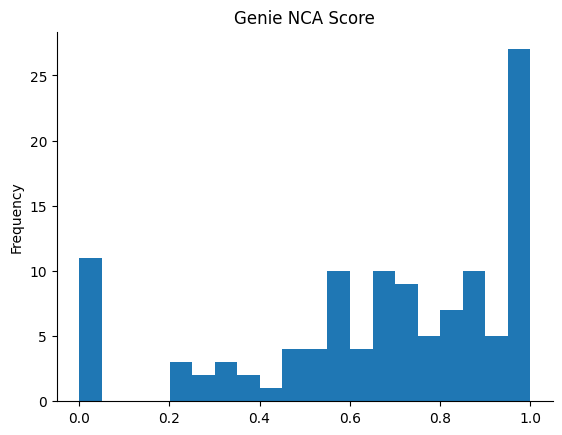

In [22]:
from matplotlib import pyplot as plt
df_baseline['Genie NCA Score'].plot(kind='hist', bins=20, title='Genie NCA Score')
plt.gca().spines[['top', 'right',]].set_visible(False)

## Execute get_scores_with_autoencoder on all datasets trying different numbers of embeddings (last hidden layer of the neural network)



In [23]:
n_embeddings_list = [2,4,8,16,32,64]

scores_lists = {}
for n_embs in tqdm.tqdm(n_embeddings_list, desc="Processing Datasets"):
  for battery in battery_datasets_dict.keys():
    for dataset in battery_datasets_dict[battery]:
      column_name = 'Genie+Autoencoder '+ str(n_embs) +' NCA Score'
      if column_name not in scores_lists:
        scores_lists[column_name] = []
      scores_lists[column_name].append(get_scores_with_autoencoder(battery, dataset, n_embeddings=n_embs))

df_ssnn = pd.DataFrame.from_dict(scores_lists)

Processing Datasets: 100%|██████████| 6/6 [09:34<00:00, 95.82s/it] 


In [24]:
df = pd.concat([df_baseline, df_ssnn], axis=1)

# Final Results

In [25]:
df['Genie+Autoencoder 2 NCA Score (Difference)'] = df['Genie+Autoencoder 2 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 4 NCA Score (Difference)'] = df['Genie+Autoencoder 4 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 8 NCA Score (Difference)'] = df['Genie+Autoencoder 8 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 16 NCA Score (Difference)'] = df['Genie+Autoencoder 16 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 32 NCA Score (Difference)'] = df['Genie+Autoencoder 32 NCA Score'] - df['Genie NCA Score']
df['Genie+Autoencoder 64 NCA Score (Difference)'] = df['Genie+Autoencoder 64 NCA Score'] - df['Genie NCA Score']

def highlight_scores(row):
    color = 'yellow'
    if row['Genie NCA Score'] < 0.8 and \
     (row['Genie+Autoencoder 2 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 4 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 8 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 16 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 32 NCA Score'] > 0.9 or
      row['Genie+Autoencoder 64 NCA Score'] > 0.9):
        return [f'background-color: {color}'] * len(row)
    return [''] * len(row)

df.style.apply(highlight_scores, axis=1)

,Battery,Dataset,Genie NCA Score,Genie+Autoencoder 2 NCA Score,Genie+Autoencoder 4 NCA Score,Genie+Autoencoder 8 NCA Score,Genie+Autoencoder 16 NCA Score,Genie+Autoencoder 32 NCA Score,Genie+Autoencoder 64 NCA Score,Genie+Autoencoder 2 NCA Score (Difference),Genie+Autoencoder 4 NCA Score (Difference),Genie+Autoencoder 8 NCA Score (Difference),Genie+Autoencoder 16 NCA Score (Difference),Genie+Autoencoder 32 NCA Score (Difference),Genie+Autoencoder 64 NCA Score (Difference)
0,fcps,atom,0.680000,0.457500,0.492500,0.202500,0.685000,0.237500,0.292500,-0.222500,-0.187500,-0.477500,0.005000,-0.442500,-0.387500
1,fcps,chainlink,0.564000,0.398000,0.524000,0.000000,0.340000,0.462000,0.374000,-0.166000,-0.040000,-0.564000,-0.224000,-0.102000,-0.190000
2,fcps,engytime,0.638031,0.605748,0.177246,0.295111,0.478131,0.399094,0.911535,-0.032283,-0.460785,-0.342920,-0.159899,-0.238937,0.273504
3,fcps,hepta,1.000000,0.922222,1.000000,1.000000,1.000000,1.000000,1.000000,-0.077778,0.000000,0.000000,0.000000,0.000000,0.000000
4,fcps,lsun,0.820000,0.585000,0.625000,0.590000,0.655000,0.540000,0.607500,-0.235000,-0.195000,-0.230000,-0.165000,-0.280000,-0.212500
5,fcps,target,0.861708,0.858953,0.853444,0.684848,0.849036,0.685950,0.847383,-0.002755,-0.008264,-0.176860,-0.012672,-0.175758,-0.014325
6,fcps,tetra,0.973333,0.863333,0.993333,0.983333,1.000000,0.930000,1.000000,-0.110000,0.020000,0.010000,0.026667,-0.043333,0.026667
7,fcps,twodiamonds,1.000000,0.832500,0.327500,0.075000,0.980000,0.997500,0.975000,-0.167500,-0.672500,-0.925000,-0.020000,-0.002500,-0.025000
8,fcps,wingnut,0.836614,0.803150,0.889764,0.907480,0.696850,0.751969,0.775591,-0.033465,0.053150,0.070866,-0.139764,-0.084646,-0.061024
9,g2mg,g2mg_4_10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
